In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# 1. 安装 unrar 工具（只需要运行一次，大约需要3秒）
!apt-get install unrar

# 2. 专门用于解压 rar 的命令（注意：这里最后的参数是 x，代表解压）
!unrar x  /content/drive/MyDrive/data.rar /content/dataset/

流式输出内容被截断，只能显示最后 5000 行内容。
Extracting  /content/dataset/train/细辛/XixinXixinXixinXixin_19.jpg         48%  OK 
Extracting  /content/dataset/train/细辛/XixinXixinXixinXixin_20.jpg         48%  OK 
Extracting  /content/dataset/train/细辛/XixinXixinXixinXixin_21.jpg         48%  OK 
Extracting  /content/dataset/train/细辛/XixinXixinXixinXixin_22.jpg         48%  OK 
Extracting  /content/dataset/train/细辛/XixinXixinXixinXixin_23.jpg         48%  OK 
Extracting  /content/dataset/train/细辛/XixinXixinXixinXixin_24.jpg         48%  OK 
Extracting  /content/dataset/train/细辛/XixinXixinXixinXixin_25.jpg         48%  OK 
Extracting  /content/dataset/train/细辛/XixinXixinXixinXixin_26.jpg         48%  OK 
Extracting  /content/dataset/train/细辛/XixinXixinXixinXixin_27.jpg         48%  OK 
Extracting  /content/dataset/train/细辛/XixinXixinXixinXixin_28.jpg         48%  OK 
Extracting  /content/dataset/train/细辛/XixinXixinXixin

In [5]:
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

test_dataset = datasets.ImageFolder('/content/dataset/val', transform=data_transforms['val'])
train_full = datasets.ImageFolder('/content/dataset/train', transform=data_transforms['train'])

val_size = int(0.1 * len(train_full))
train_size = len(train_full) - val_size

train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

print("数据集划分成功：")
print("训练集:", len(train_dataset))
print("验证集:", len(val_dataset))
print("测试集:", len(test_dataset))
print("类别数:", len(train_full.classes))

数据集划分成功：
训练集: 6767
验证集: 751
测试集: 1767
类别数: 93


manual_seed(42)让你每次切分结果一致，论文更可复现。

num_workers=0更适合 Colab，减少卡顿。

batch_size=16更保险，先跑通再加大。

len(train_full.classes)直接拿类别数，避免子集对象问题。 **加粗文字**

EfficientNetB0模型

加载模型

In [6]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 93)
model = model.to(device)

print(model.classifier)

Device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 153MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=93, bias=True)
)


这一步是在做迁移学习：直接用预训练权重，再把最后分类头改成你的 93 类任务。

In [7]:
import os

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

checkpoint_path = "/content/drive/MyDrive/efficientnetb0_best.pth"
start_epoch = 0
best_acc = 0.0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_acc = checkpoint['best_acc']
    print(f"Resumed from epoch {start_epoch}")
else:
    print("No checkpoint found, start from scratch")

Resumed from epoch 8


训练和验证函数

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:
        images, labels = batch
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            images, labels = batch
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return running_loss / total, correct / total

跑 20个 epoch

In [9]:
num_epochs = 20
train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(start_epoch, num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_acc': best_acc
        }, checkpoint_path)
        print(f"Saved best checkpoint at epoch {epoch+1}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [9/20] Train Loss: 0.3511, Train Acc: 0.9113, Val Loss: 0.7206, Val Acc: 0.8149
Epoch [10/20] Train Loss: 0.2914, Train Acc: 0.9280, Val Loss: 0.7312, Val Acc: 0.8176
Epoch [11/20] Train Loss: 0.2494, Train Acc: 0.9322, Val Loss: 0.7621, Val Acc: 0.8096
Epoch [12/20] Train Loss: 0.2030, Train Acc: 0.9495, Val Loss: 0.7411, Val Acc: 0.8149
Epoch [13/20] Train Loss: 0.1851, Train Acc: 0.9529, Val Loss: 0.8164, Val Acc: 0.8149
Epoch [14/20] Train Loss: 0.1656, Train Acc: 0.9539, Val Loss: 0.7907, Val Acc: 0.8083
Epoch [15/20] Train Loss: 0.1496, Train Acc: 0.9614, Val Loss: 0.8191, Val Acc: 0.8189
Epoch [16/20] Train Loss: 0.1264, Train Acc: 0.9679, Val Loss: 0.8308, Val Acc: 0.8162
Epoch [17/20] Train Loss: 0.1265, Train Acc: 0.9665, Val Loss: 0.8252, Val Acc: 0.8256
Epoch [18/20] Train Loss: 0.1015, Train Acc: 0.9735, Val Loss: 0.8703, Val Acc: 0.8256
Epoch [19/20] Train Loss: 0.1092, Train Acc: 0.9713, Val Loss: 0.9050, Val Acc: 0.8083
Epoch [20/20] Train Loss: 0.0953, Train Acc:

画训练曲线

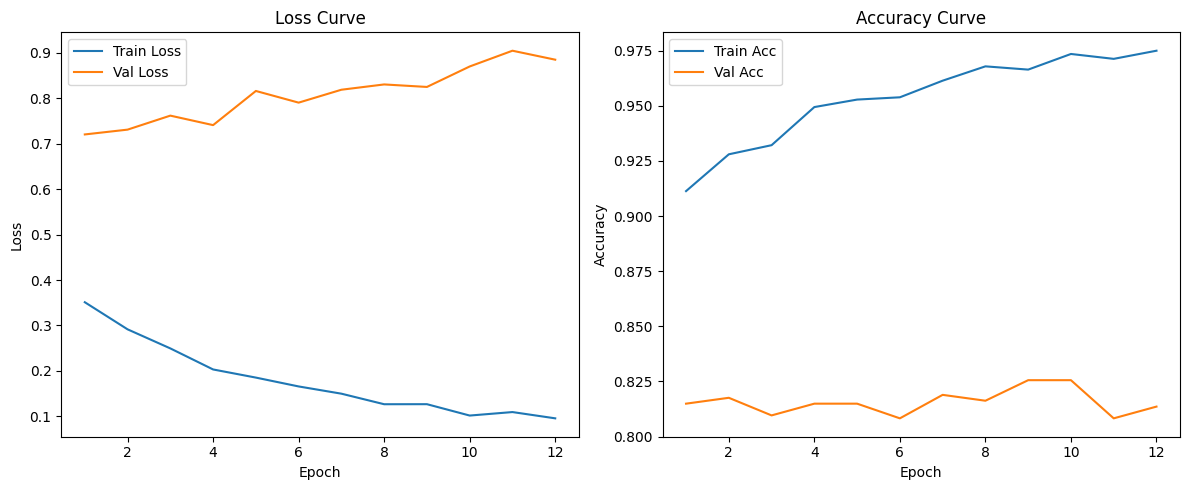

In [10]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label='Train Acc')
plt.plot(epochs, val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()

训练已经稳定，下一步就是在 test_loader上跑最终测试。
你要得到：

测试损失。

测试准确率。

混淆矩阵。

每类分类报告。

测试代码

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def test_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            images, labels = batch
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_labels, all_preds


test_loss, test_acc, y_true, y_pred = test_model(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Test Loss: 0.8305, Test Acc: 0.8200


生成混淆矩阵

In [12]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[12  0  0 ...  0  0  0]
 [ 0 17  0 ...  0  0  0]
 [ 0  0 14 ...  1  0  0]
 ...
 [ 0  0  0 ... 15  0  0]
 [ 0  0  0 ...  0 11  0]
 [ 0  0  0 ...  0  1 15]]


生成分类报告

In [13]:
print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

           0     1.0000    0.6316    0.7742        19
           1     0.8947    0.8947    0.8947        19
           2     0.7000    0.7368    0.7179        19
           3     0.7500    0.6316    0.6857        19
           4     0.8500    0.8947    0.8718        19
           5     0.8947    0.8947    0.8947        19
           6     0.9000    0.9474    0.9231        19
           7     0.7619    0.8421    0.8000        19
           8     0.8824    0.7895    0.8333        19
           9     0.6923    0.9474    0.8000        19
          10     0.6923    0.4737    0.5625        19
          11     0.6429    0.4737    0.5455        19
          12     0.8261    1.0000    0.9048        19
          13     0.7778    0.7368    0.7568        19
          14     0.6364    0.7368    0.6829        19
          15     0.8889    0.8421    0.8649        19
          16     0.8182    0.9474    0.8780        19
          17     0.8824    

混淆矩阵图

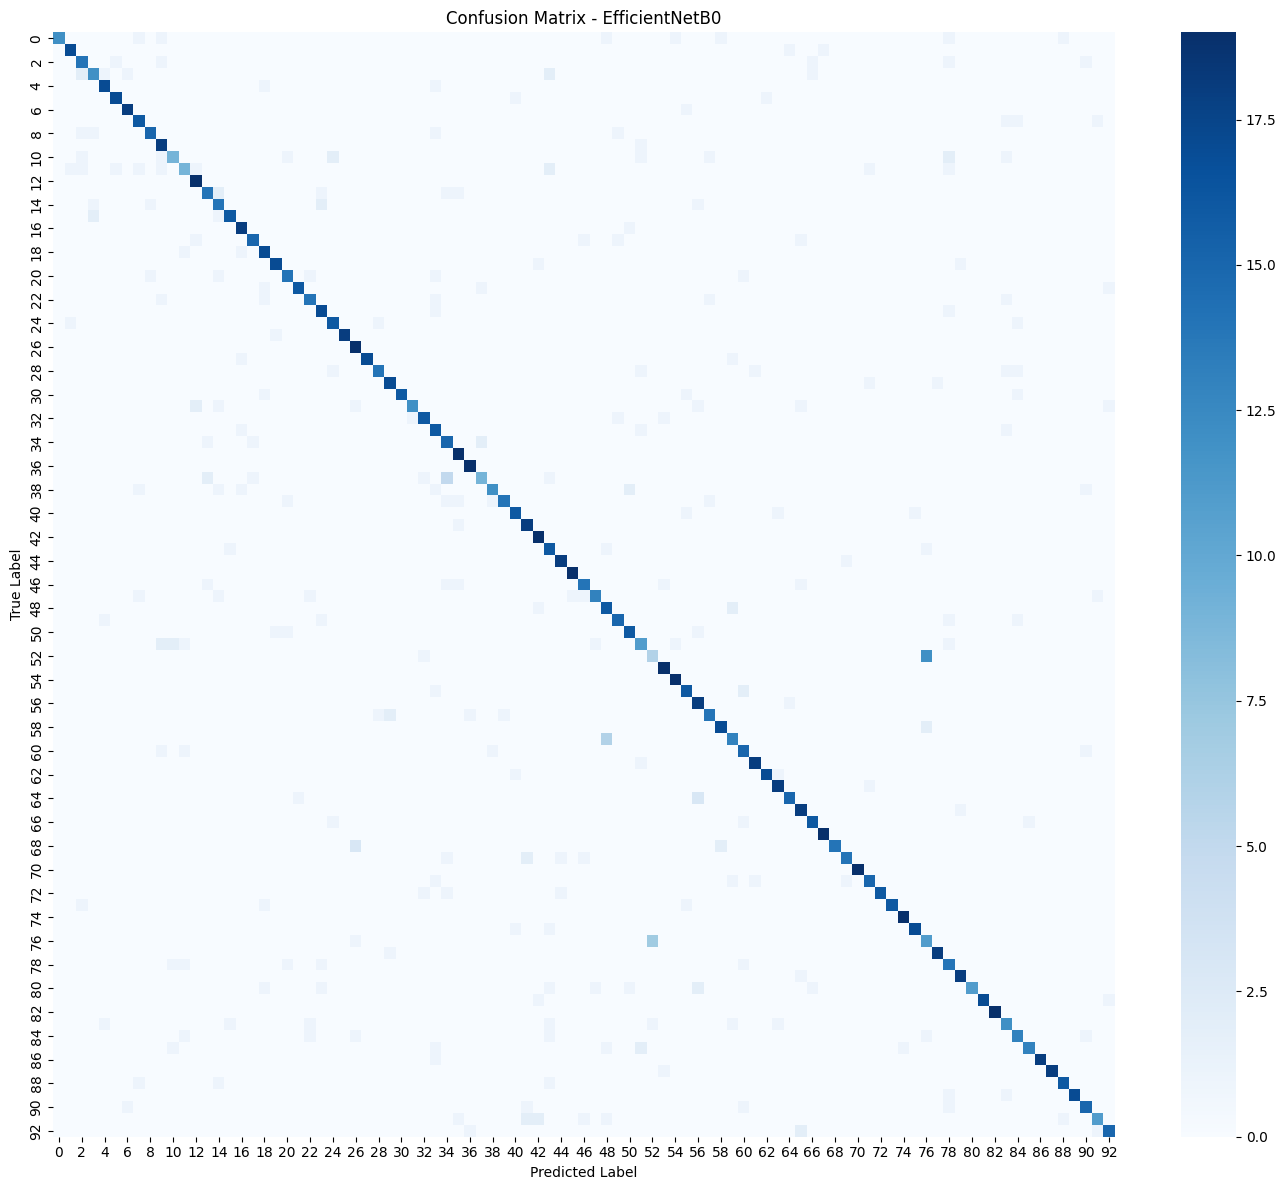

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", annot=False)
plt.title("Confusion Matrix - EfficientNetB0")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

MobileNetV2 原版代码

In [15]:
import torch
import torch.nn as nn
import torchvision.models as models
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model_mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model_mobilenet.classifier[1] = nn.Linear(model_mobilenet.classifier[1].in_features, 93)
model_mobilenet = model_mobilenet.to(device)

print(model_mobilenet.classifier)

Device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 128MB/s]

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=93, bias=True)
)


损失函数和优化器

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_mobilenet.parameters(), lr=1e-4)

checkpoint_path = "/content/drive/MyDrive/mobilenetv2_best.pth"
start_epoch = 0
best_acc = 0.0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model_mobilenet.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_acc = checkpoint["best_acc"]
    print(f"Resumed from epoch {start_epoch}")
else:
    print("No checkpoint found, start from scratch")

Resumed from epoch 19


训练 20 轮

In [17]:
num_epochs = 20
train_losses_mob, train_accs_mob = [], []
val_losses_mob, val_accs_mob = [], []

for epoch in range(start_epoch, num_epochs):
    train_loss, train_acc = train_one_epoch(model_mobilenet, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model_mobilenet, val_loader, criterion, device)

    train_losses_mob.append(train_loss)
    train_accs_mob.append(train_acc)
    val_losses_mob.append(val_loss)
    val_accs_mob.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": model_mobilenet.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_acc": best_acc
        }, checkpoint_path)
        print(f"Saved best checkpoint at epoch {epoch+1}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [20/20] Train Loss: 0.0963, Train Acc: 0.9786, Val Loss: 0.9504, Val Acc: 0.8029


测试部分

In [18]:
checkpoint = torch.load(checkpoint_path, map_location=device)
model_mobilenet.load_state_dict(checkpoint["model_state_dict"])
model_mobilenet = model_mobilenet.to(device)

test_loss_mob, test_acc_mob, y_true_mob, y_pred_mob = test_model(
    model_mobilenet, test_loader, criterion, device
)

print(f"MobileNetV2 Test Loss: {test_loss_mob:.4f}")
print(f"MobileNetV2 Test Acc: {test_acc_mob:.4f}")
print(classification_report(y_true_mob, y_pred_mob, digits=4))

MobileNetV2 Test Loss: 0.8778
MobileNetV2 Test Acc: 0.8098
              precision    recall  f1-score   support

           0     1.0000    0.5789    0.7333        19
           1     0.8333    0.7895    0.8108        19
           2     0.6800    0.8947    0.7727        19
           3     0.9286    0.6842    0.7879        19
           4     0.8235    0.7368    0.7778        19
           5     0.7647    0.6842    0.7222        19
           6     0.8261    1.0000    0.9048        19
           7     0.7895    0.7895    0.7895        19
           8     0.8235    0.7368    0.7778        19
           9     0.8571    0.9474    0.9000        19
          10     0.6842    0.6842    0.6842        19
          11     0.5833    0.7368    0.6512        19
          12     0.8500    0.8947    0.8718        19
          13     0.9167    0.5789    0.7097        19
          14     0.5200    0.6842    0.5909        19
          15     0.7895    0.7895    0.7895        19
          16     0.888

混淆矩阵

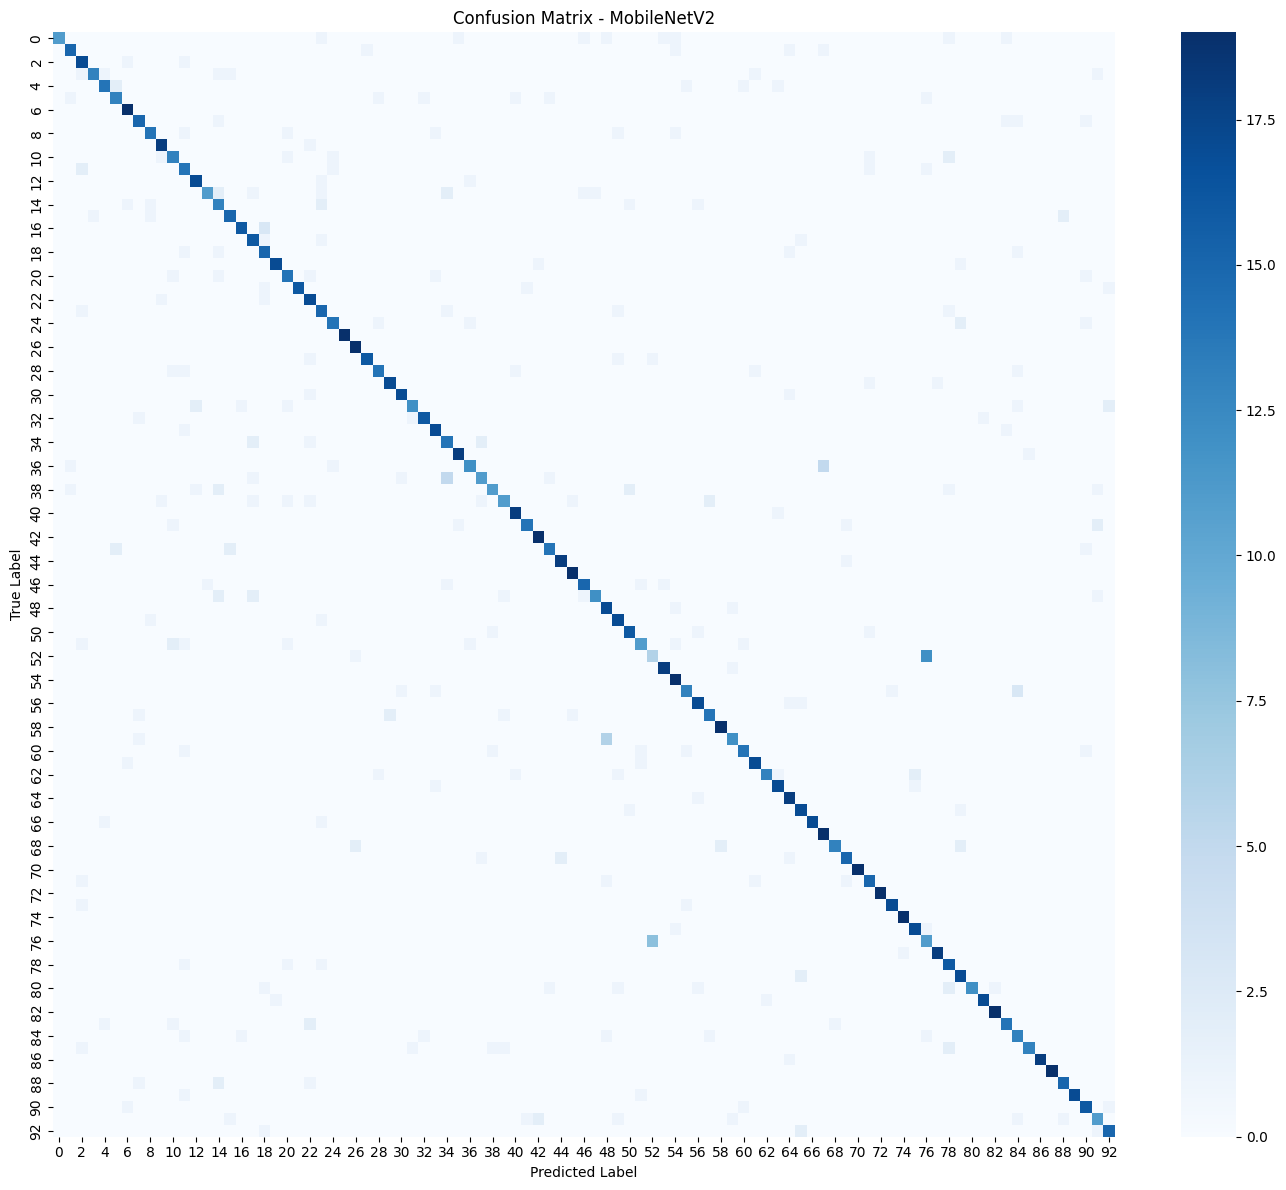

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_mob = confusion_matrix(y_true_mob, y_pred_mob)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_mob, cmap="Blues")
plt.title("Confusion Matrix - MobileNetV2")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix_mobilenetv2.png", dpi=300, bbox_inches="tight")
plt.show()

训练曲线

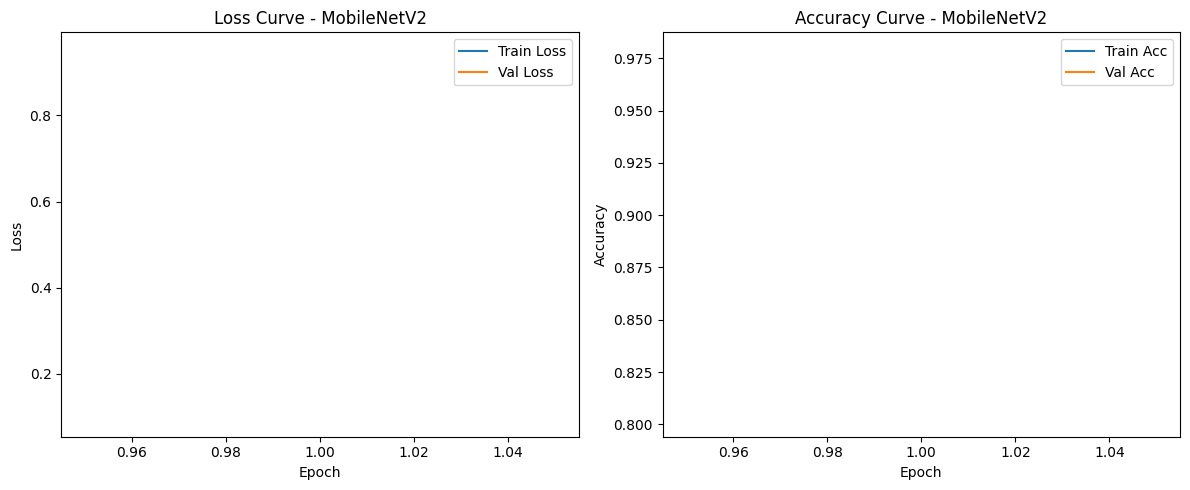

In [20]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses_mob) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses_mob, label='Train Loss')
plt.plot(epochs, val_losses_mob, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve - MobileNetV2')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs_mob, label='Train Acc')
plt.plot(epochs, val_accs_mob, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve - MobileNetV2')
plt.legend()

plt.tight_layout()
plt.savefig("training_curves_mobilenetv2.png", dpi=300, bbox_inches="tight")
plt.show()

ResNet50 代码

In [21]:
import torch
import torch.nn as nn
import torchvision.models as models
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model_resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 93)
model_resnet = model_resnet.to(device)

print(model_resnet.fc)

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


Linear(in_features=2048, out_features=93, bias=True)


损失函数和优化器

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_resnet.parameters(), lr=1e-4)

checkpoint_path = "/content/drive/MyDrive/resnet50_best.pth"
start_epoch = 0
best_acc = 0.0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model_resnet.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    best_acc = checkpoint["best_acc"]
    print(f"Resumed from epoch {start_epoch}")
else:
    print("No checkpoint found, start from scratch")

No checkpoint found, start from scratch


训练 20 轮

In [23]:
num_epochs = 20
train_losses_res, train_accs_res = [], []
val_losses_res, val_accs_res = [], []

for epoch in range(start_epoch, num_epochs):
    train_loss, train_acc = train_one_epoch(model_resnet, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model_resnet, val_loader, criterion, device)

    train_losses_res.append(train_loss)
    train_accs_res.append(train_acc)
    val_losses_res.append(val_loss)
    val_accs_res.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": model_resnet.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_acc": best_acc
        }, checkpoint_path)
        print(f"Saved best checkpoint at epoch {epoch+1}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/20] Train Loss: 2.5909, Train Acc: 0.4206, Val Loss: 1.1895, Val Acc: 0.7031
Saved best checkpoint at epoch 1
Epoch [2/20] Train Loss: 1.0899, Train Acc: 0.7251, Val Loss: 0.9358, Val Acc: 0.7696
Saved best checkpoint at epoch 2
Epoch [3/20] Train Loss: 0.7291, Train Acc: 0.8138, Val Loss: 0.8215, Val Acc: 0.7816
Saved best checkpoint at epoch 3
Epoch [4/20] Train Loss: 0.4886, Train Acc: 0.8735, Val Loss: 0.8575, Val Acc: 0.7936
Saved best checkpoint at epoch 4
Epoch [5/20] Train Loss: 0.3695, Train Acc: 0.9000, Val Loss: 0.8432, Val Acc: 0.7949
Saved best checkpoint at epoch 5
Epoch [6/20] Train Loss: 0.2634, Train Acc: 0.9328, Val Loss: 0.7820, Val Acc: 0.8189
Saved best checkpoint at epoch 6
Epoch [7/20] Train Loss: 0.2077, Train Acc: 0.9440, Val Loss: 0.9387, Val Acc: 0.7896
Epoch [8/20] Train Loss: 0.1529, Train Acc: 0.9583, Val Loss: 0.9327, Val Acc: 0.7816
Epoch [9/20] Train Loss: 0.1392, Train Acc: 0.9632, Val Loss: 0.8044, Val Acc: 0.8176
Epoch [10/20] Train Loss: 0.

测试部分

In [24]:
checkpoint = torch.load(checkpoint_path, map_location=device)
model_resnet.load_state_dict(checkpoint["model_state_dict"])
model_resnet = model_resnet.to(device)

test_loss_res, test_acc_res, y_true_res, y_pred_res = test_model(
    model_resnet, test_loader, criterion, device
)

print(f"ResNet50 Test Loss: {test_loss_res:.4f}")
print(f"ResNet50 Test Acc: {test_acc_res:.4f}")
print(classification_report(y_true_res, y_pred_res, digits=4))

ResNet50 Test Loss: 0.8802
ResNet50 Test Acc: 0.8308
              precision    recall  f1-score   support

           0     1.0000    0.5263    0.6897        19
           1     0.7727    0.8947    0.8293        19
           2     0.8824    0.7895    0.8333        19
           3     0.7222    0.6842    0.7027        19
           4     1.0000    0.8947    0.9444        19
           5     0.7500    0.7895    0.7692        19
           6     0.7600    1.0000    0.8636        19
           7     0.6000    0.7895    0.6818        19
           8     1.0000    0.6842    0.8125        19
           9     0.6667    0.8421    0.7442        19
          10     1.0000    0.4737    0.6429        19
          11     0.5909    0.6842    0.6341        19
          12     1.0000    0.8947    0.9444        19
          13     0.8421    0.8421    0.8421        19
          14     0.9412    0.8421    0.8889        19
          15     0.6667    0.8421    0.7442        19
          16     0.8571    0

混淆矩阵

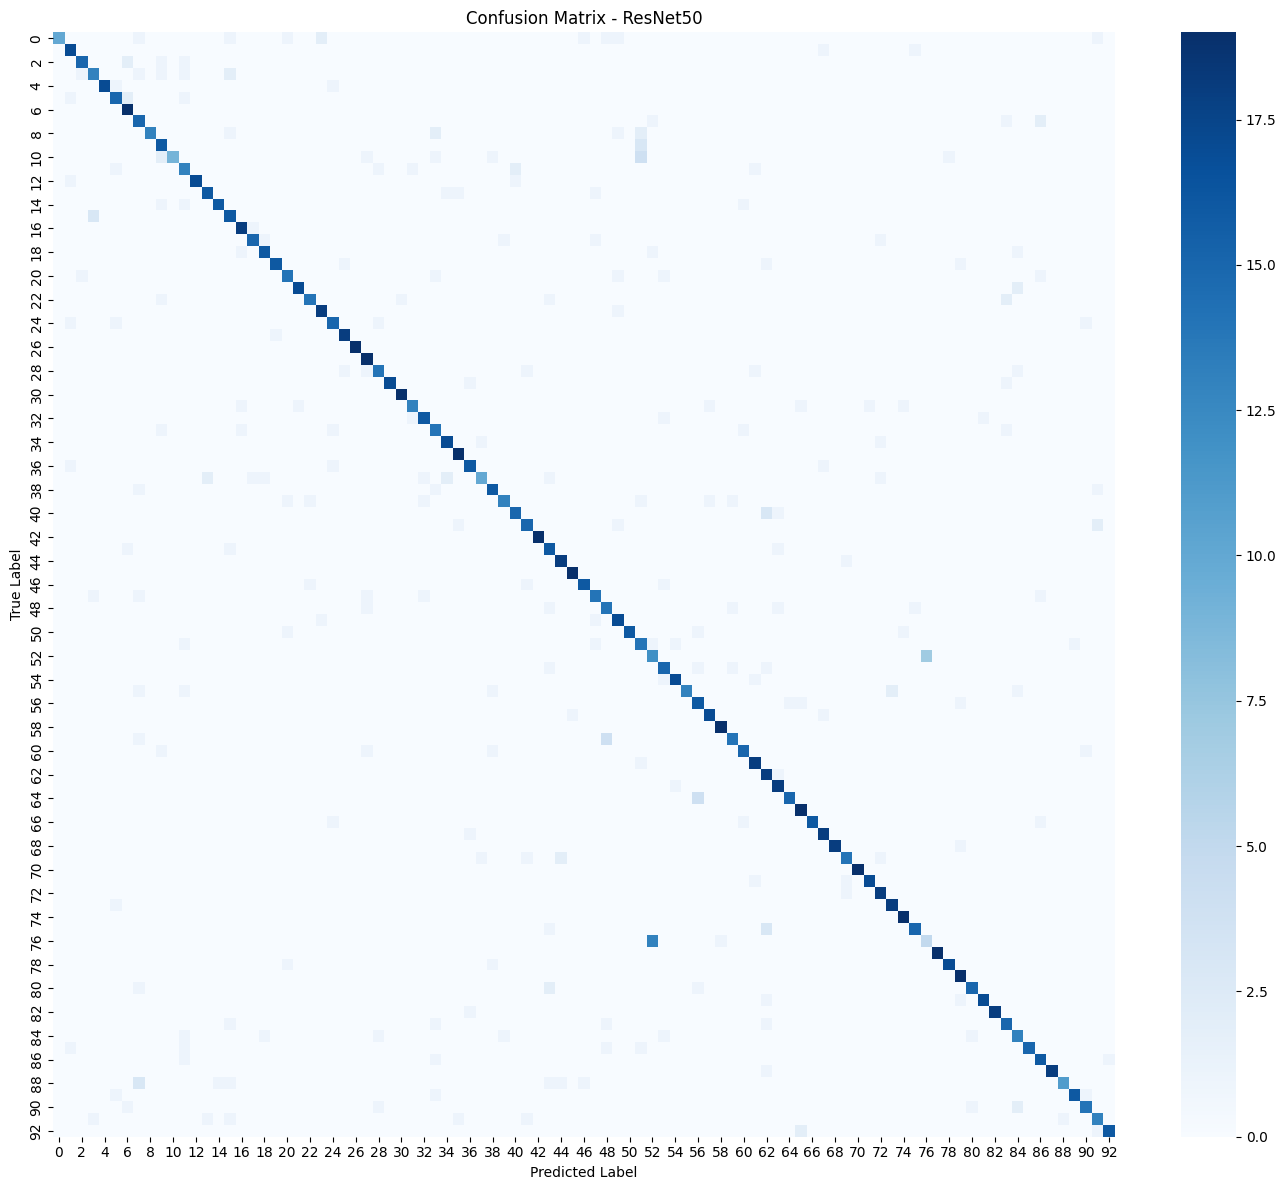

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_res = confusion_matrix(y_true_res, y_pred_res)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_res, cmap="Blues")
plt.title("Confusion Matrix - ResNet50")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix_resnet50.png", dpi=300, bbox_inches="tight")
plt.show()

训练曲线

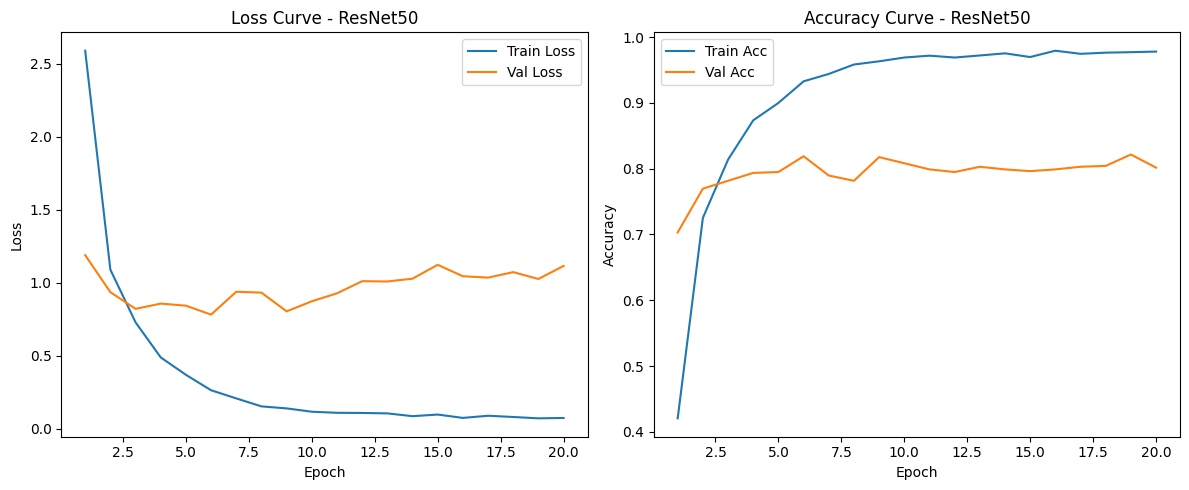

In [26]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses_res) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses_res, label='Train Loss')
plt.plot(epochs, val_losses_res, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve - ResNet50')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs_res, label='Train Acc')
plt.plot(epochs, val_accs_res, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve - ResNet50')
plt.legend()

plt.tight_layout()
plt.savefig("training_curves_resnet50.png", dpi=300, bbox_inches="tight")
plt.show()

MobileNetV2强增强版
随机裁剪。
随机旋转。
颜色扰动。
更强的尺度变化。

In [27]:
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torchvision.models as models
import os

In [28]:
data_transforms_aug = {
    'train': transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

In [29]:
test_dataset_aug = datasets.ImageFolder('/content/dataset/val', transform=data_transforms_aug['val'])
train_full_aug = datasets.ImageFolder('/content/dataset/train', transform=data_transforms_aug['train'])

val_size = int(0.1 * len(train_full_aug))
train_size = len(train_full_aug) - val_size

train_dataset_aug, val_dataset_aug = random_split(
    train_full_aug,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=16, shuffle=True, num_workers=0)
val_loader_aug = DataLoader(val_dataset_aug, batch_size=16, shuffle=False, num_workers=0)
test_loader_aug = DataLoader(test_dataset_aug, batch_size=16, shuffle=False, num_workers=0)

print("增强版数据集划分成功：")
print("训练集:", len(train_dataset_aug))
print("验证集:", len(val_dataset_aug))
print("测试集:", len(test_dataset_aug))
print("类别数:", len(train_full_aug.classes))

增强版数据集划分成功：
训练集: 6767
验证集: 751
测试集: 1767
类别数: 93


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model_aug = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model_aug.classifier[1] = nn.Linear(model_aug.classifier[1].in_features, 93)
model_aug = model_aug.to(device)

criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=1e-4)

checkpoint_path_aug = "mobilenetv2_aug_best.pth"
best_acc_aug = 0.0
start_epoch_aug = 0

if os.path.exists(checkpoint_path_aug):
    checkpoint = torch.load(checkpoint_path_aug, map_location=device)
    model_aug.load_state_dict(checkpoint["model_state_dict"])
    optimizer_aug.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch_aug = checkpoint["epoch"] + 1
    best_acc_aug = checkpoint["best_acc"]
    print(f"Resumed from epoch {start_epoch_aug}")
else:
    print("No checkpoint found, start from scratch")

Device: cuda
No checkpoint found, start from scratch


In [31]:
num_epochs = 20
train_losses_aug, train_accs_aug = [], []
val_losses_aug, val_accs_aug = [], []

for epoch in range(start_epoch_aug, num_epochs):
    train_loss, train_acc = train_one_epoch(model_aug, train_loader_aug, criterion_aug, optimizer_aug, device)
    val_loss, val_acc = evaluate(model_aug, val_loader_aug, criterion_aug, device)

    train_losses_aug.append(train_loss)
    train_accs_aug.append(train_acc)
    val_losses_aug.append(val_loss)
    val_accs_aug.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_acc_aug:
        best_acc_aug = val_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": model_aug.state_dict(),
            "optimizer_state_dict": optimizer_aug.state_dict(),
            "best_acc": best_acc_aug
        }, checkpoint_path_aug)
        print(f"Saved best checkpoint at epoch {epoch+1}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/20] Train Loss: 3.7373, Train Acc: 0.2153, Val Loss: 2.4670, Val Acc: 0.4807
Saved best checkpoint at epoch 1
Epoch [2/20] Train Loss: 2.2991, Train Acc: 0.4751, Val Loss: 1.6715, Val Acc: 0.6085
Saved best checkpoint at epoch 2
Epoch [3/20] Train Loss: 1.7560, Train Acc: 0.5883, Val Loss: 1.3538, Val Acc: 0.6804
Saved best checkpoint at epoch 3
Epoch [4/20] Train Loss: 1.4646, Train Acc: 0.6397, Val Loss: 1.2248, Val Acc: 0.7031
Saved best checkpoint at epoch 4
Epoch [5/20] Train Loss: 1.2449, Train Acc: 0.6940, Val Loss: 1.1189, Val Acc: 0.7230
Saved best checkpoint at epoch 5
Epoch [6/20] Train Loss: 1.0906, Train Acc: 0.7240, Val Loss: 1.0229, Val Acc: 0.7390
Saved best checkpoint at epoch 6
Epoch [7/20] Train Loss: 0.9796, Train Acc: 0.7511, Val Loss: 0.9422, Val Acc: 0.7670
Saved best checkpoint at epoch 7
Epoch [8/20] Train Loss: 0.8991, Train Acc: 0.7689, Val Loss: 0.9748, Val Acc: 0.7510
Epoch [9/20] Train Loss: 0.7935, Train Acc: 0.8008, Val Loss: 0.9747, Val Acc: 0.

In [32]:
checkpoint = torch.load(checkpoint_path_aug, map_location=device)
model_aug.load_state_dict(checkpoint["model_state_dict"])
model_aug = model_aug.to(device)

test_loss_aug, test_acc_aug, y_true_aug, y_pred_aug = test_model(
    model_aug, test_loader_aug, criterion_aug, device
)

print(f"MobileNetV2 Aug Test Loss: {test_loss_aug:.4f}")
print(f"MobileNetV2 Aug Test Acc: {test_acc_aug:.4f}")
print(classification_report(y_true_aug, y_pred_aug, digits=4))

MobileNetV2 Aug Test Loss: 0.8554
MobileNetV2 Aug Test Acc: 0.7946
              precision    recall  f1-score   support

           0     0.8667    0.6842    0.7647        19
           1     0.9412    0.8421    0.8889        19
           2     0.8095    0.8947    0.8500        19
           3     0.6667    0.7368    0.7000        19
           4     1.0000    0.7368    0.8485        19
           5     0.8000    0.6316    0.7059        19
           6     0.9375    0.7895    0.8571        19
           7     0.7143    0.5263    0.6061        19
           8     0.8000    0.8421    0.8205        19
           9     0.5625    0.4737    0.5143        19
          10     0.6000    0.4737    0.5294        19
          11     0.6190    0.6842    0.6500        19
          12     0.6429    0.9474    0.7660        19
          13     0.9167    0.5789    0.7097        19
          14     0.5484    0.8947    0.6800        19
          15     0.7895    0.7895    0.7895        19
          16  

画图

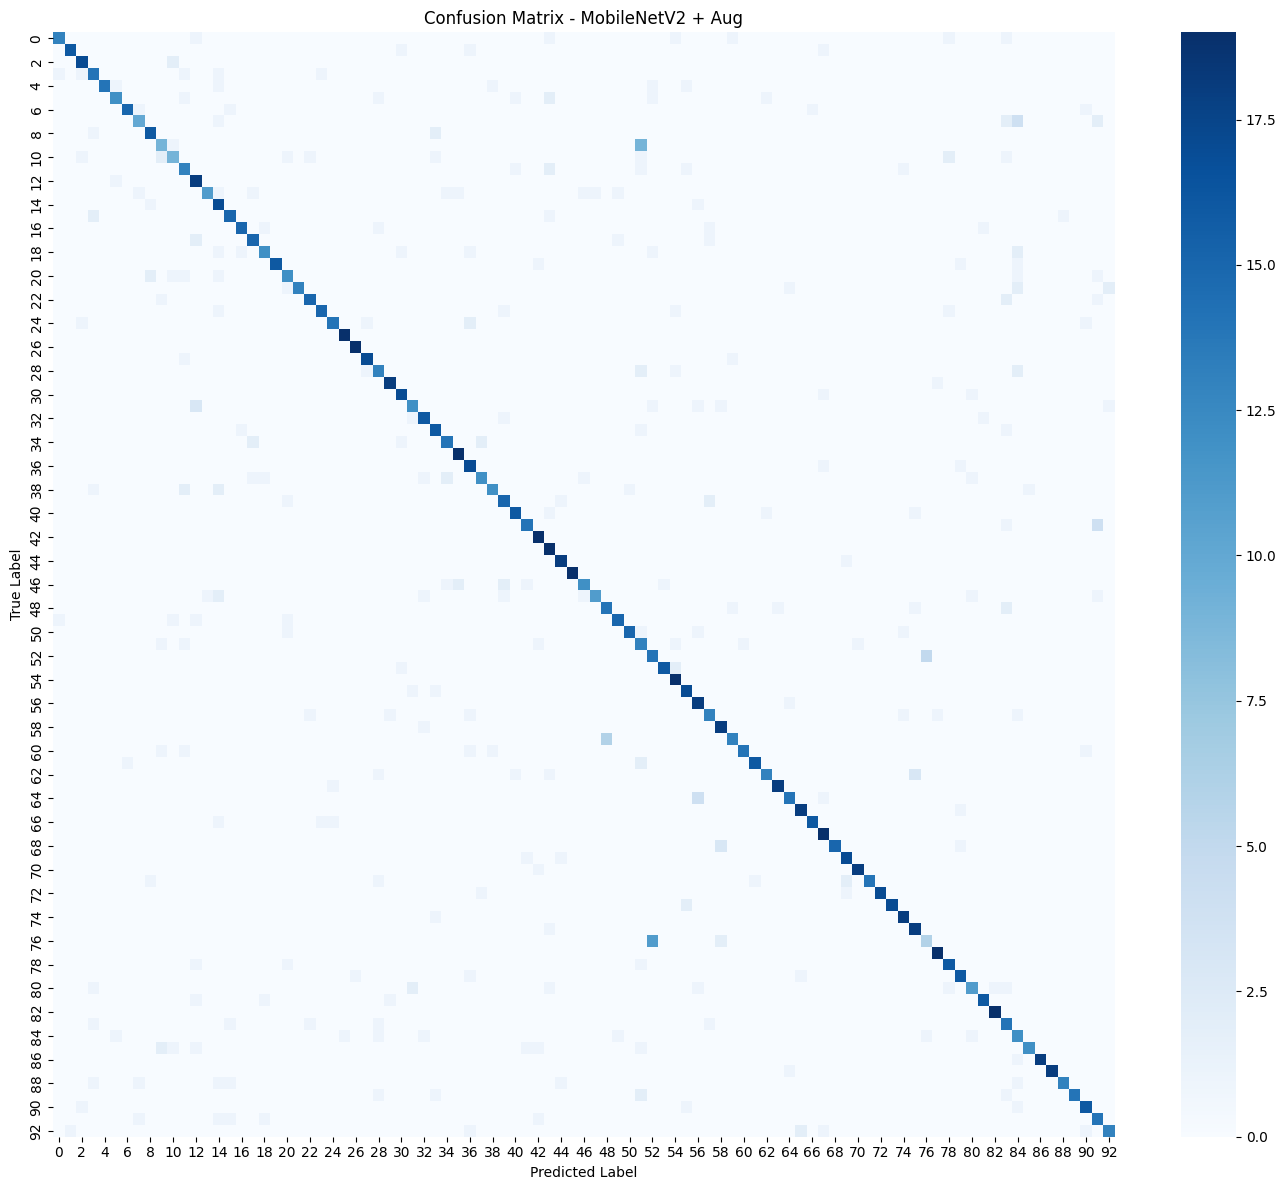

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_aug = confusion_matrix(y_true_aug, y_pred_aug)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_aug, cmap="Blues")
plt.title("Confusion Matrix - MobileNetV2 + Aug")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix_mobilenetv2_aug.png", dpi=300, bbox_inches="tight")
plt.show()

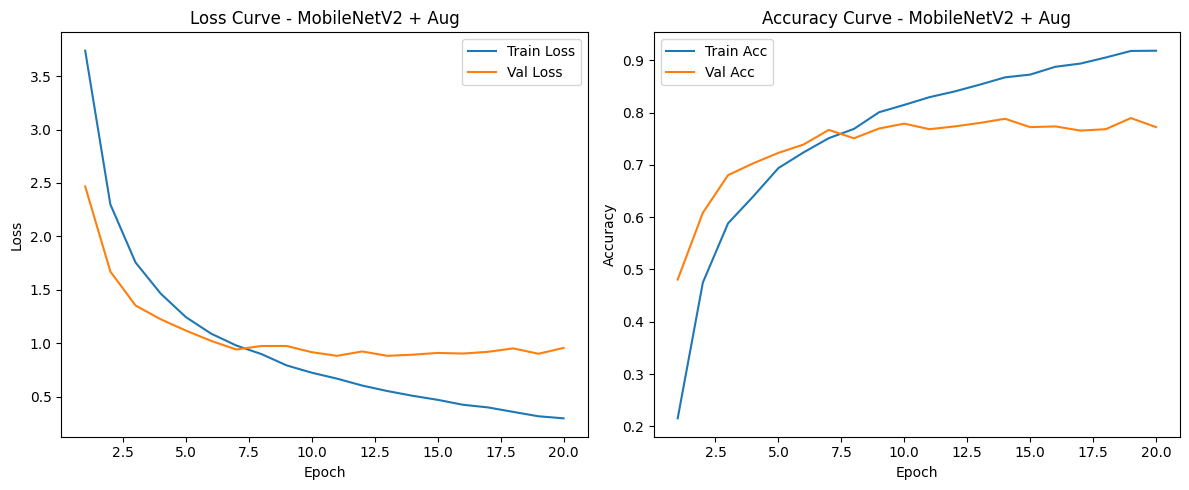

In [34]:
epochs = range(1, len(train_losses_aug) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses_aug, label='Train Loss')
plt.plot(epochs, val_losses_aug, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve - MobileNetV2 + Aug')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs_aug, label='Train Acc')
plt.plot(epochs, val_accs_aug, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve - MobileNetV2 + Aug')
plt.legend()

plt.tight_layout()
plt.savefig("training_curves_mobilenetv2_aug.png", dpi=300, bbox_inches="tight")
plt.show()

**MobileNetV2 + CBAM **

1. 导入依赖
这段是导入 PyTorch、模型和保存路径相关库。

In [35]:
import torch
import torch.nn as nn
import torchvision.models as models
import os

2. 通道注意力模块
这段实现 CBAM 里的 Channel Attention，作用是给更重要的通道更高权重。

In [36]:
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc1 = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)

3. 空间注意力模块
这段实现 CBAM 里的 Spatial Attention，作用是让模型关注图像里更关键的位置。

In [37]:
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        assert kernel_size in (3, 7)
        padding = 3 if kernel_size == 7 else 1
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv(x)
        return self.sigmoid(x)

4. CBAM 总模块
这段把通道注意力和空间注意力串起来，形成完整的 CBAM。

In [38]:
class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio=ratio)
        self.sa = SpatialAttention(kernel_size=kernel_size)

    def forward(self, x):
        x = self.ca(x) * x
        x = self.sa(x) * x
        return x

5. MobileNetV2 + CBAM 模型
这段是在 MobileNetV2 的最后特征层后面加上 CBAM，再接分类器。

In [39]:
class MobileNetV2_CBAM(nn.Module):
    def __init__(self, num_classes=93):
        super(MobileNetV2_CBAM, self).__init__()
        base_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        self.features = base_model.features
        self.cbam = CBAM(1280)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

6. 初始化设备和模型
这段是设置 GPU/CPU、初始化模型、损失函数和优化器。

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model_cbam = MobileNetV2_CBAM(num_classes=93).to(device)

criterion_cbam = nn.CrossEntropyLoss()
optimizer_cbam = torch.optim.Adam(model_cbam.parameters(), lr=1e-4)

Device: cuda


7. 设置 checkpoint 路径
这段是保存最优模型的路径，以及断点续训相关变量。

In [41]:
checkpoint_path_cbam = "/content/drive/MyDrive/mobilenetv2_cbam_best.pth"
best_acc_cbam = 0.0
start_epoch_cbam = 0

8. 读取已有 checkpoint
这段是判断之前有没有训练过，如果有就接着训练。

In [42]:
if os.path.exists(checkpoint_path_cbam):
    checkpoint = torch.load(checkpoint_path_cbam, map_location=device)
    model_cbam.load_state_dict(checkpoint["model_state_dict"])
    optimizer_cbam.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch_cbam = checkpoint["epoch"] + 1
    best_acc_cbam = checkpoint["best_acc"]
    print(f"Resumed from epoch {start_epoch_cbam}")
else:
    print("No checkpoint found, start from scratch")

Resumed from epoch 8


9. 训练过程
这段是训练 CBAM 模型，每个 epoch 都会验证一次，并保存最好结果。

In [43]:
num_epochs = 20
train_losses_cbam, train_accs_cbam = [], []
val_losses_cbam, val_accs_cbam = [], []

for epoch in range(start_epoch_cbam, num_epochs):
    train_loss, train_acc = train_one_epoch(model_cbam, train_loader, criterion_cbam, optimizer_cbam, device)
    val_loss, val_acc = evaluate(model_cbam, val_loader, criterion_cbam, device)

    train_losses_cbam.append(train_loss)
    train_accs_cbam.append(train_acc)
    val_losses_cbam.append(val_loss)
    val_accs_cbam.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_acc_cbam:
        best_acc_cbam = val_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": model_cbam.state_dict(),
            "optimizer_state_dict": optimizer_cbam.state_dict(),
            "best_acc": best_acc_cbam
        }, checkpoint_path_cbam)
        print(f"Saved best checkpoint at epoch {epoch+1}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [9/20] Train Loss: 0.4288, Train Acc: 0.9017, Val Loss: 0.7936, Val Acc: 0.8016
Epoch [10/20] Train Loss: 0.3475, Train Acc: 0.9209, Val Loss: 0.8409, Val Acc: 0.7843
Epoch [11/20] Train Loss: 0.2933, Train Acc: 0.9308, Val Loss: 0.8406, Val Acc: 0.7989
Epoch [12/20] Train Loss: 0.2463, Train Acc: 0.9430, Val Loss: 0.8428, Val Acc: 0.7856
Epoch [13/20] Train Loss: 0.2072, Train Acc: 0.9527, Val Loss: 0.8752, Val Acc: 0.7883
Epoch [14/20] Train Loss: 0.1788, Train Acc: 0.9591, Val Loss: 0.8186, Val Acc: 0.7976
Epoch [15/20] Train Loss: 0.1592, Train Acc: 0.9622, Val Loss: 0.9093, Val Acc: 0.7736
Epoch [16/20] Train Loss: 0.1392, Train Acc: 0.9684, Val Loss: 0.8864, Val Acc: 0.7883
Epoch [17/20] Train Loss: 0.1253, Train Acc: 0.9713, Val Loss: 0.9525, Val Acc: 0.7883
Epoch [18/20] Train Loss: 0.1063, Train Acc: 0.9750, Val Loss: 0.9510, Val Acc: 0.7936
Epoch [19/20] Train Loss: 0.0992, Train Acc: 0.9767, Val Loss: 0.9486, Val Acc: 0.7923
Epoch [20/20] Train Loss: 0.0949, Train Acc:

10. 测试集评估
这段是加载最优模型，并在测试集上做最终评估。

In [44]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import torch

def test_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            images, labels = batch
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_labels, all_preds

checkpoint = torch.load(checkpoint_path_cbam, map_location=device)
model_cbam.load_state_dict(checkpoint["model_state_dict"])
model_cbam = model_cbam.to(device)

test_loss_cbam, test_acc_cbam, y_true_cbam, y_pred_cbam = test_model(
    model_cbam, test_loader, criterion_cbam, device
)

print(f"MobileNetV2+CBAM Test Loss: {test_loss_cbam:.4f}")
print(f"MobileNetV2+CBAM Test Acc: {test_acc_cbam:.4f}")
print(classification_report(y_true_cbam, y_pred_cbam, digits=4))

MobileNetV2+CBAM Test Loss: 0.7415
MobileNetV2+CBAM Test Acc: 0.8263
              precision    recall  f1-score   support

           0     0.9231    0.6316    0.7500        19
           1     0.8889    0.8421    0.8649        19
           2     0.8182    0.9474    0.8780        19
           3     0.7647    0.6842    0.7222        19
           4     0.7273    0.8421    0.7805        19
           5     0.8000    0.8421    0.8205        19
           6     0.9000    0.9474    0.9231        19
           7     0.8125    0.6842    0.7429        19
           8     0.8000    0.8421    0.8205        19
           9     0.7600    1.0000    0.8636        19
          10     0.6316    0.6316    0.6316        19
          11     0.7500    0.7895    0.7692        19
          12     0.8500    0.8947    0.8718        19
          13     0.8235    0.7368    0.7778        19
          14     0.6087    0.7368    0.6667        19
          15     0.6957    0.8421    0.7619        19
          16

11. 混淆矩阵
这段是画测试集混淆矩阵图。

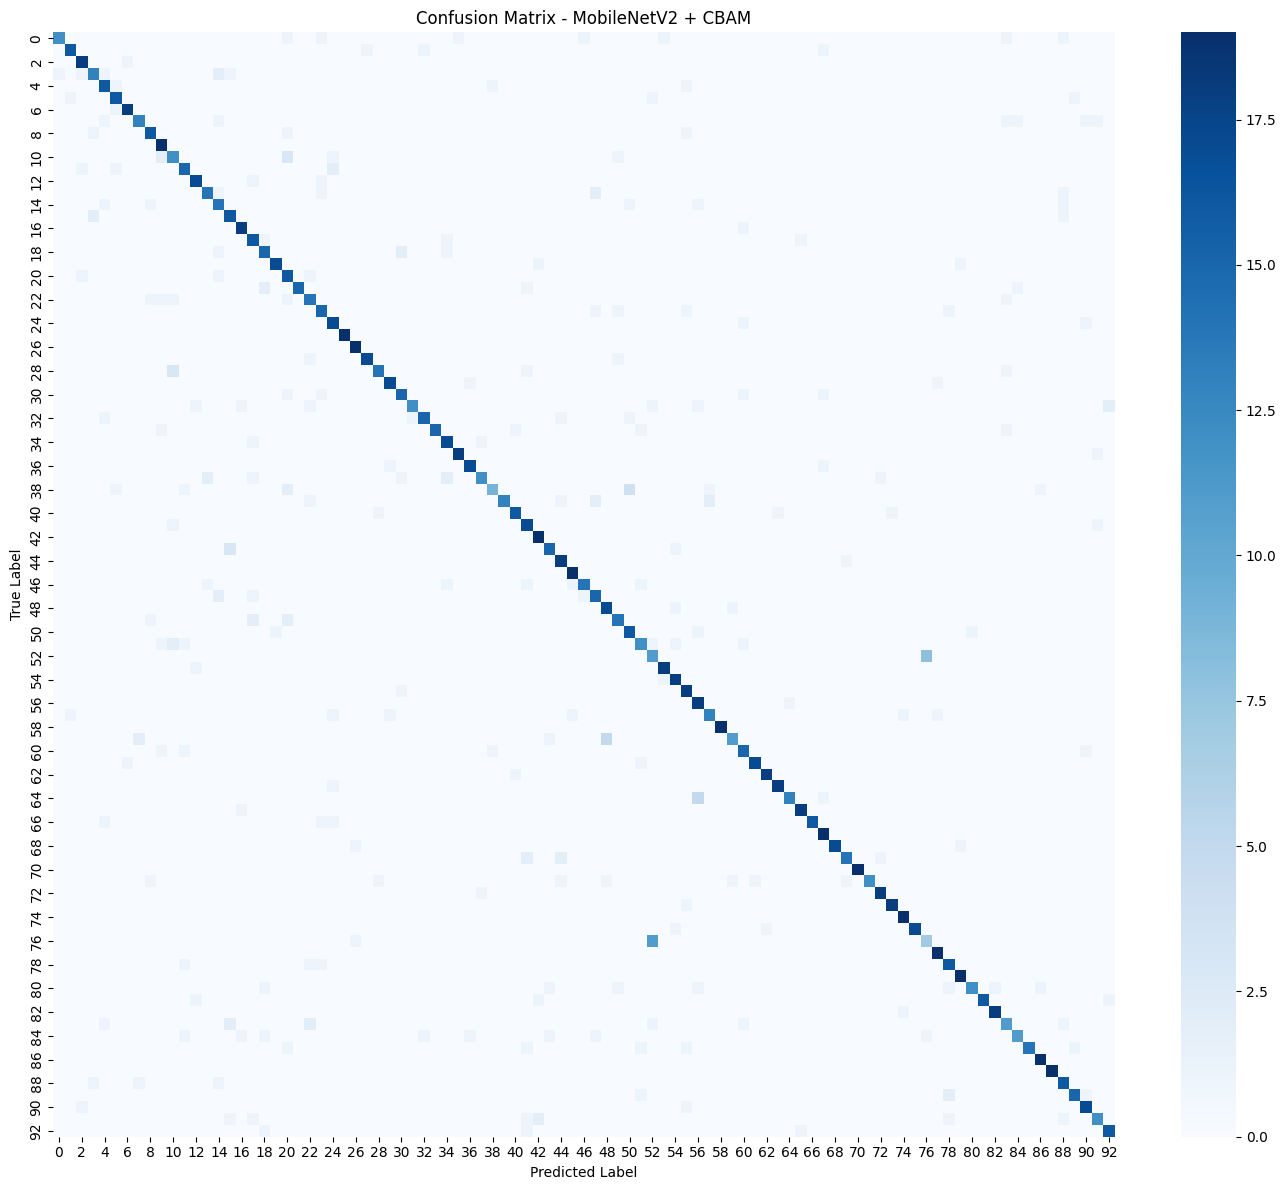

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_cbam = confusion_matrix(y_true_cbam, y_pred_cbam)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_cbam, cmap="Blues")
plt.title("Confusion Matrix - MobileNetV2 + CBAM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix_mobilenetv2_cbam.png", dpi=300, bbox_inches="tight")
plt.show()

12. 训练曲线
这段是画 loss 和 accuracy 曲线。

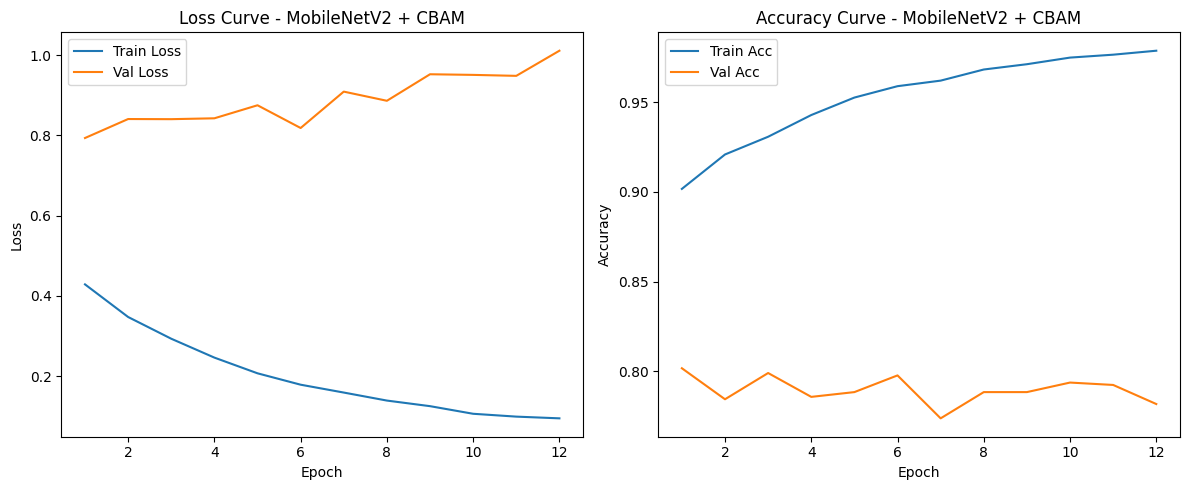

In [46]:
epochs = range(1, len(train_losses_cbam) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses_cbam, label='Train Loss')
plt.plot(epochs, val_losses_cbam, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve - MobileNetV2 + CBAM')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs_cbam, label='Train Acc')
plt.plot(epochs, val_accs_cbam, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve - MobileNetV2 + CBAM')
plt.legend()

plt.tight_layout()
plt.savefig("training_curves_mobilenetv2_cbam.png", dpi=300, bbox_inches="tight")
plt.show()

轻增强版 MobileNetV2

In [47]:
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import os
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# =====================
# 1. 数据增强策略
# =====================
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1,
            saturation=0.1,
            hue=0.02
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
}

# =====================
# 2. 数据集
# =====================
train_full = datasets.ImageFolder(
    '/content/dataset/train',
    transform=data_transforms['train']
)

test_dataset = datasets.ImageFolder(
    '/content/dataset/val',
    transform=data_transforms['val']
)

# =====================
# 3. 划分训练集和验证集
# =====================
val_size = int(0.1 * len(train_full))
train_size = len(train_full) - val_size

train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# 验证集使用测试阶段的预处理
val_dataset.dataset.transform = data_transforms['val']

# =====================
# 4. DataLoader
# =====================
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print("数据集划分成功：")
print("训练集:", len(train_dataset))
print("验证集:", len(val_dataset))
print("测试集:", len(test_dataset))
print("类别数:", len(train_full.classes))

# =====================
# 5. MobileNetV2 模型
# =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(train_full.classes))
model = model.to(device)

# =====================
# 6. 损失函数和优化器
# =====================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# =====================
# 7. 训练和验证函数
# =====================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

# =====================
# 8. 训练主循环
# =====================
num_epochs = 20
best_acc = 0.0
checkpoint_path = "mobilenetv2_light_aug_best.pth"

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_acc": best_acc
        }, checkpoint_path)
        print(f"Saved best checkpoint at epoch {epoch+1}")

print(f"Best Val Acc: {best_acc:.4f}")

# =====================
# 9. 测试集评估
# =====================
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"MobileNetV2 Light Aug Test Loss: {test_loss:.4f}")
print(f"MobileNetV2 Light Aug Test Acc: {test_acc:.4f}")

数据集划分成功：
训练集: 6767
验证集: 751
测试集: 1767
类别数: 93
Device: cuda


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/20] Train Loss: 3.6070, Train Acc: 0.2632, Val Loss: 2.2323, Val Acc: 0.5566
Saved best checkpoint at epoch 1
Epoch [2/20] Train Loss: 2.0009, Train Acc: 0.5728, Val Loss: 1.4054, Val Acc: 0.6831
Saved best checkpoint at epoch 2
Epoch [3/20] Train Loss: 1.4113, Train Acc: 0.6860, Val Loss: 1.1145, Val Acc: 0.7297
Saved best checkpoint at epoch 3
Epoch [4/20] Train Loss: 1.0874, Train Acc: 0.7486, Val Loss: 0.9966, Val Acc: 0.7537
Saved best checkpoint at epoch 4
Epoch [5/20] Train Loss: 0.8478, Train Acc: 0.8045, Val Loss: 0.8799, Val Acc: 0.7816
Saved best checkpoint at epoch 5
Epoch [6/20] Train Loss: 0.6743, Train Acc: 0.8456, Val Loss: 0.8622, Val Acc: 0.7816
Epoch [7/20] Train Loss: 0.5321, Train Acc: 0.8781, Val Loss: 0.8278, Val Acc: 0.7896
Saved best checkpoint at epoch 7
Epoch [8/20] Train Loss: 0.4178, Train Acc: 0.9039, Val Loss: 0.8019, Val Acc: 0.8056
Saved best checkpoint at epoch 8
Epoch [9/20] Train Loss: 0.3074, Train Acc: 0.9353, Val Loss: 0.8199, Val Acc: 0.

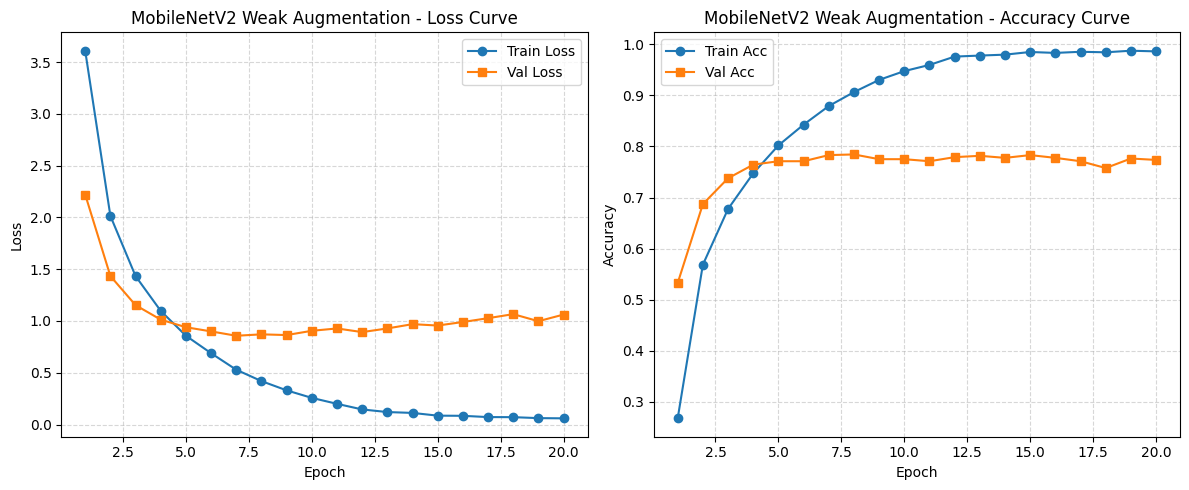

In [48]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, 21)

train_loss = [
    3.6102, 2.0150, 1.4336, 1.0977, 0.8576,
    0.6887, 0.5292, 0.4195, 0.3301, 0.2574,
    0.2000, 0.1458, 0.1205, 0.1122, 0.0858,
    0.0842, 0.0719, 0.0712, 0.0619, 0.0598
]

val_loss = [
    2.2211, 1.4341, 1.1529, 1.0131, 0.9398,
    0.8994, 0.8573, 0.8710, 0.8641, 0.9052,
    0.9279, 0.8927, 0.9280, 0.9694, 0.9560,
    0.9902, 1.0271, 1.0660, 0.9979, 1.0621
]

train_acc = [
    0.2678, 0.5685, 0.6776, 0.7473, 0.8020,
    0.8426, 0.8790, 0.9063, 0.9302, 0.9474,
    0.9595, 0.9758, 0.9778, 0.9796, 0.9848,
    0.9830, 0.9852, 0.9842, 0.9873, 0.9860
]

val_acc = [
    0.5326, 0.6871, 0.7377, 0.7643, 0.7710,
    0.7710, 0.7830, 0.7843, 0.7750, 0.7750,
    0.7710, 0.7790, 0.7816, 0.7776, 0.7830,
    0.7776, 0.7710, 0.7577, 0.7763, 0.7736
]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='s', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MobileNetV2 Weak Augmentation - Loss Curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, marker='o', label='Train Acc')
plt.plot(epochs, val_acc, marker='s', label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MobileNetV2 Weak Augmentation - Accuracy Curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('mobilenetv2_weak_aug_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [49]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

# 收集测试集所有真实标签和预测标签
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().tolist())
        all_preds.extend(preds.cpu().tolist())

# 打印分类报告（每一类的 P/R/F1）
print("=== MobileNetV2 Light Aug Classification Report ===")
print(classification_report(
    all_labels,
    all_preds,
    target_names=test_dataset.classes,
    digits=4
))

# 提取 Macro 三项指标
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average='macro'
)

print(f"MobileNetV2 Light Aug Macro Precision: {macro_p:.4f}")
print(f"MobileNetV2 Light Aug Macro Recall:    {macro_r:.4f}")
print(f"MobileNetV2 Light Aug Macro F1:        {macro_f1:.4f}")

=== MobileNetV2 Light Aug Classification Report ===
              precision    recall  f1-score   support

         丝瓜络     0.9000    0.4737    0.6207        19
         九香虫     0.8889    0.8421    0.8649        19
         五加皮     0.8500    0.8947    0.8718        19
          人参     0.7647    0.6842    0.7222        19
          僵蚕     0.8000    0.8421    0.8205        19
          全蝎     0.8667    0.6842    0.7647        19
        冬虫夏草     0.9444    0.8947    0.9189        19
         北沙参     0.8667    0.6842    0.7647        19
         千年健     0.9286    0.6842    0.7879        19
         合欢皮     0.7727    0.8947    0.8293        19
         土荆皮     0.6000    0.4737    0.5294        19
          地龙     0.7143    0.7895    0.7500        19
         大腹皮     0.7308    1.0000    0.8444        19
         天花粉     0.7500    0.7895    0.7692        19
          天麻     0.5714    0.6316    0.6000        19
         太子参     0.8000    0.8421    0.8205        19
         安息香     0.8421    0.

药材类与名称对比

In [50]:
print("类别名称列表:", train_full.classes)
print("名称到索引的映射:", train_full.class_to_idx)

类别名称列表: ['丝瓜络', '九香虫', '五加皮', '人参', '僵蚕', '全蝎', '冬虫夏草', '北沙参', '千年健', '合欢皮', '土荆皮', '地龙', '大腹皮', '天花粉', '天麻', '太子参', '安息香', '山奈', '山慈菇', '山茱萸', '川木香', '川楝子', '川牛膝', '干姜', '木丁香', '枸杞子', '柏子仁', '桂枝', '桑寄生', '桑椹', '桑螵蛸', '槟榔', '橘核', '沉香', '浙贝母', '海螵蛸', '淡豆豉', '湖北贝母', '灵芝', '瓦楞子', '甘松', '甘草', '番泻叶', '白前', '白扁豆', '白矾', '白芍', '白芷', '白茅根', '白蔹', '石榴皮', '秦皮', '稻芽', '竹茹', '细辛', '羌活', '肉豆蔻', '自然铜', '芥子', '芦根', '苍术', '苏木', '苦地丁', '荆芥穗', '草豆蔻', '荔枝核', '荜拨', '荜澄茄', '莱菔子', '莲子', '莲子心', '莲房', '薏苡仁', '藁本', '蜂房', '谷精草', '谷芽', '路路通', '郁金', '酸枣仁', '金果榄', '金灯笼', '金钱白花蛇', '银柴胡', '防风', '鳖甲', '鸡内金', '鸡冠花', '麦冬', '黄柏', '黄芩', '黄芪', '龙眼肉']
名称到索引的映射: {'丝瓜络': 0, '九香虫': 1, '五加皮': 2, '人参': 3, '僵蚕': 4, '全蝎': 5, '冬虫夏草': 6, '北沙参': 7, '千年健': 8, '合欢皮': 9, '土荆皮': 10, '地龙': 11, '大腹皮': 12, '天花粉': 13, '天麻': 14, '太子参': 15, '安息香': 16, '山奈': 17, '山慈菇': 18, '山茱萸': 19, '川木香': 20, '川楝子': 21, '川牛膝': 22, '干姜': 23, '木丁香': 24, '枸杞子': 25, '柏子仁': 26, '桂枝': 27, '桑寄生': 28, '桑椹': 29, '桑螵蛸': 30, '槟榔': 31, '橘核': 32, '沉香': 33, '浙贝母': 34, '海螵

热力图

In [51]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 67.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=76c4afde23751ca1948d05420eb26a34e8bad9dffb4b7b333d4d40ebd49c1ab9
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


加载原版 MobileNetV2 模型和权重

In [52]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 1) 构建原版 MobileNetV2 结构（注意 num_classes 要和你训练时一致）
train_full = datasets.ImageFolder('/content/dataset/train')
num_classes = len(train_full.classes)

model = models.mobilenet_v2(weights=None)  # 用你训练时的结构
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model = model.to(device)

# 2) 加载你训练好的权重（改成你的实际路径）
checkpoint = torch.load("/content/drive/MyDrive/mobilenetv2_best.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])  # 如果你保存的是 dict
model.eval()

print("Loaded MobileNetV2 checkpoint, best_val_acc =", checkpoint.get("best_acc", "N/A"))

Device: cuda
Loaded MobileNetV2 checkpoint, best_val_acc = 0.8055925432756325


In [53]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

test_dataset = datasets.ImageFolder(
    '/content/dataset/val',
    transform=val_transform
)
print("测试集大小:", len(test_dataset))
print("类别数:", len(test_dataset.classes))

测试集大小: 1767
类别数: 93


In [54]:
from pytorch_grad_cam import GradCAM

target_layers = [model.features[-1]]  # 注意：是列表

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

从测试集中拿一张图，生成热力图

In [55]:
# 想看的类别索引（例如 52：稻芽）
target_class = 72

# 在测试集中找到所有属于这个类的样本索引
indices = [i for i, (_, y) in enumerate(test_dataset.samples) if y == target_class]

if len(indices) == 0:
    print(f"验证集中没有找到类 {target_class} 的样本")
else:
    # 选该类中的第 1 张图（你也可以改成 indices[k] 看别的）
    idx = indices[0]

    # 从 ImageFolder 里取 tensor 和标签
    img_tensor, label = test_dataset[idx]
    img_path = test_dataset.samples[idx][0]
    img_pil = Image.open(img_path).convert("RGB")

    # 构造 batch 维度
    input_tensor = img_tensor.unsqueeze(0).to(device)

    print("选中的样本 idx:", idx)
    print("True label idx:", label, "=>", test_dataset.classes[label])
    print("Image path:", img_path)

选中的样本 idx: 1368
True label idx: 72 => 薏苡仁
Image path: /content/dataset/val/薏苡仁/Yiyiren101.jpg


生成 Grad-CAM 热力图并叠加到原图：

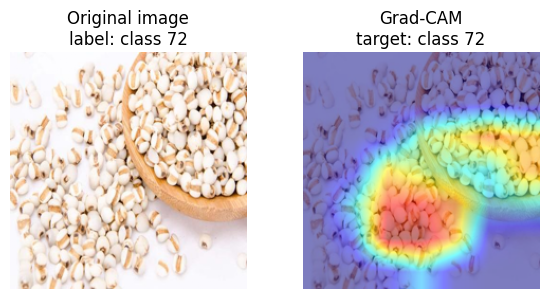

In [56]:
# 原始图像转为 [0,1] 的 numpy 数组
rgb_img = np.array(img_pil.resize((224, 224))).astype(np.float32) / 255.0

# 生成热力图 (默认解释最高概率类别)
grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]  # [H_cam, W_cam]

# 叠加到原图
cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# 显示和保存
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title(f"Original image\nlabel: class {label}", fontsize=12)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cam_image)
plt.title(f"Grad-CAM\ntarget: class {target_class}", fontsize=12)
plt.axis("off")

plt.tight_layout()
plt.show()

# 保存到 Google Drive 方便插论文
Image.fromarray((cam_image * 255).astype(np.uint8)).save(
    "/content/drive/MyDrive/mobilenetv2_gradcam_example1.jpg"
)

 MobileNetV2 + CBAM热力图编程

1. 构建 MobileNetV2 + CBAM 模型并加载权重

In [57]:
# 如果你的模型写在单独文件里，就取消注释并改文件名
# from your_model_file import MobileNetV2_CBAM

In [58]:
# 1) 读取类别数
train_full = datasets.ImageFolder('/content/dataset/train')
num_classes = len(train_full.classes)

# 2) 构建 MobileNetV2 + CBAM 模型
model = MobileNetV2_CBAM(num_classes=num_classes)
model = model.to(device)

# 3) 加载训练好的权重
checkpoint_path_cbam = "/content/drive/MyDrive/mobilenetv2_cbam_best.pth"
checkpoint = torch.load(checkpoint_path_cbam, map_location=device)

# 如果你保存的是包含 model_state_dict 的 checkpoint
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
    print("Loaded CBAM checkpoint, best_val_acc =", checkpoint.get("best_acc", "N/A"))
else:
    # 如果你保存的是纯 state_dict
    model.load_state_dict(checkpoint)
    print("Loaded CBAM state_dict")

model.eval()

Loaded CBAM checkpoint, best_val_acc = 0.8042609853528628


MobileNetV2_CBAM(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96,

2. 测试集预处理

In [59]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

test_dataset = datasets.ImageFolder(
    '/content/dataset/val',
    transform=val_transform
)

print("测试集大小:", len(test_dataset))
print("类别数:", len(test_dataset.classes))

测试集大小: 1767
类别数: 93


3. 选择 Grad-CAM 的目标层

In [60]:
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

4. 选择一张测试图并进行预测

In [61]:
# 想看的类别索引（例如 52：稻芽）
target_class = 72

# 在测试集中找到所有属于这个类的样本索引
indices = [i for i, (_, y) in enumerate(test_dataset.samples) if y == target_class]

if len(indices) == 0:
    print(f"验证集中没有找到类 {target_class} 的样本")
else:
    # 选该类中的第 1 张图（你也可以改成 indices[k] 看别的）
    idx = indices[0]

    # 从 ImageFolder 里取 tensor 和标签
    img_tensor, label = test_dataset[idx]
    img_path = test_dataset.samples[idx][0]
    img_pil = Image.open(img_path).convert("RGB")

    # 构造 batch 维度
    input_tensor = img_tensor.unsqueeze(0).to(device)

    print("选中的样本 idx:", idx)
    print("True label idx:", label, "=>", test_dataset.classes[label])
    print("Image path:", img_path)

选中的样本 idx: 1368
True label idx: 72 => 薏苡仁
Image path: /content/dataset/val/薏苡仁/Yiyiren101.jpg


5. 生成热力图

In [62]:
# 原始图像转为 [0,1] 的 numpy 数组
rgb_img = np.array(img_pil.resize((224, 224))).astype(np.float32) / 255.0

# 生成 Grad-CAM 热力图
grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]

# 叠加到原图
cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

6. 显示并保存图片

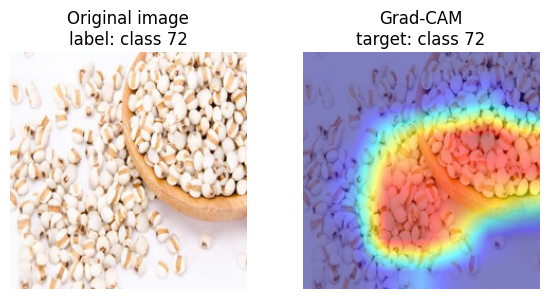

Saved: /content/drive/MyDrive/mobilenetv2_cbam_gradcam_example1.jpg


In [63]:
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title(f"Original image\nlabel: class {label}", fontsize=12)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cam_image)
plt.title(f"Grad-CAM\ntarget: class {target_class}", fontsize=12)
plt.axis("off")

plt.tight_layout()
plt.show()

# 保存到 Google Drive
Image.fromarray((cam_image * 255).astype(np.uint8)).save(
    "/content/drive/MyDrive/mobilenetv2_cbam_gradcam_example1.jpg"
)
print("Saved: /content/drive/MyDrive/mobilenetv2_cbam_gradcam_example1.jpg")

同一张图片的两个 Grad-CAM 灰度图

In [64]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ------------- 原版 MobileNetV2 -------------
# 构建原版模型并加载权重
train_full = datasets.ImageFolder('/content/dataset/train')
num_classes = len(train_full.classes)

model_base = models.mobilenet_v2(weights=None)
model_base.classifier[1] = nn.Linear(model_base.classifier[1].in_features, num_classes)
model_base = model_base.to(device)

checkpoint_base = torch.load("/content/drive/MyDrive/mobilenetv2_best.pth", map_location=device)
if isinstance(checkpoint_base, dict) and "model_state_dict" in checkpoint_base:
    model_base.load_state_dict(checkpoint_base["model_state_dict"])
else:
    model_base.load_state_dict(checkpoint_base)
model_base.eval()

# Grad-CAM 对象（原版）
target_layers_base = [model_base.features[-1]]
cam_base = GradCAM(model=model_base, target_layers=target_layers_base)

# ------------- MobileNetV2 + CBAM -------------
# 构建 CBAM 模型并加载权重
model_cbam = MobileNetV2_CBAM(num_classes=num_classes)
model_cbam = model_cbam.to(device)

checkpoint_path_cbam = "/content/drive/MyDrive/mobilenetv2_cbam_best.pth"
checkpoint_cbam = torch.load(checkpoint_path_cbam, map_location=device)
if isinstance(checkpoint_cbam, dict) and "model_state_dict" in checkpoint_cbam:
    model_cbam.load_state_dict(checkpoint_cbam["model_state_dict"])
else:
    model_cbam.load_state_dict(checkpoint_cbam)
model_cbam.eval()

# Grad-CAM 对象（CBAM）
target_layers_cbam = [model_cbam.features[-1]]
cam_cbam = GradCAM(model=model_cbam, target_layers=target_layers_cbam)

In [65]:
# 选一张测试集图片
target_class = 72
img_tensor, label = test_dataset[idx]
img_pil = Image.open(test_dataset.samples[idx][0]).convert("RGB")

input_tensor = img_tensor.unsqueeze(0).to(device)

# 原版预测 + Grad-CAM
with torch.no_grad():
    output_base = model_base(input_tensor)
pred_class_base = output_base.argmax(dim=1).item()

grayscale_cam_base = cam_base(input_tensor=input_tensor, targets=None)[0]

# CBAM 预测 + Grad-CAM
with torch.no_grad():
    output_cbam = model_cbam(input_tensor)
pred_class_cbam = output_cbam.argmax(dim=1).item()

grayscale_cam_cbam = cam_cbam(input_tensor=input_tensor, targets=None)[0]

print("Base pred:", pred_class_base, "CBAM pred:", pred_class_cbam)

Base pred: 72 CBAM pred: 72


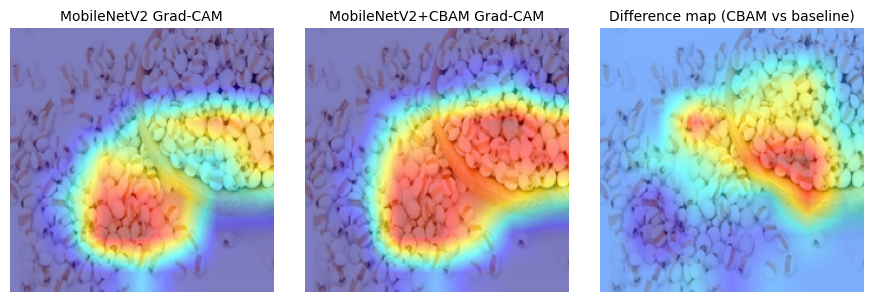

In [66]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 统一大小
H, W = grayscale_cam_base.shape

base_norm = grayscale_cam_base - grayscale_cam_base.min()
base_norm /= (base_norm.max() + 1e-8)

cbam_norm = grayscale_cam_cbam - grayscale_cam_cbam.min()
cbam_norm /= (cbam_norm.max() + 1e-8)

diff = cbam_norm - base_norm
diff_clipped = np.clip(diff, -1.0, 1.0)

rgb_img = np.array(img_pil.resize((W, H))).astype(np.float32) / 255.0

# 归一化后做伪彩色
diff_norm = (diff_clipped - diff_clipped.min()) / (diff_clipped.max() - diff_clipped.min() + 1e-8)
diff_heatmap = np.uint8(255 * diff_norm)

# 用 JET 就好，版本肯定支持
diff_heatmap = cv2.applyColorMap(diff_heatmap, cv2.COLORMAP_JET)
diff_heatmap_rgb = cv2.cvtColor(diff_heatmap, cv2.COLOR_BGR2RGB)

alpha = 0.5
overlay = diff_heatmap_rgb.astype(np.float32) / 255.0 * alpha + rgb_img * (1 - alpha)
overlay = np.clip(overlay, 0, 1)

plt.figure(figsize=(9, 3))

plt.subplot(1, 3, 1)
plt.imshow(show_cam_on_image(rgb_img, base_norm, use_rgb=True))
plt.title("MobileNetV2 Grad-CAM", fontsize=10)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(show_cam_on_image(rgb_img, cbam_norm, use_rgb=True))
plt.title("MobileNetV2+CBAM Grad-CAM", fontsize=10)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Difference map (CBAM vs baseline)", fontsize=10)
plt.axis("off")

plt.tight_layout()
plt.show()

In [67]:
from PIL import Image
Image.fromarray((overlay * 255).astype(np.uint8)).save(
    "/content/drive/MyDrive/gradcam_diff_class37.jpg"
)

In [68]:
import shutil
shutil.copy("mobilenetv2_aug_best.pth", "/content/drive/MyDrive/mobilenetv2_aug_best.pth")
shutil.copy("mobilenetv2_light_aug_best.pth", "/content/drive/MyDrive/mobilenetv2_light_aug_best.pth")
print("已保存到Drive")

已保存到Drive


In [69]:
import os, csv, json
import torch
from torchvision import datasets
from torch.utils.data import random_split

OUT_DIR = "/content/drive/MyDrive/manifests_out"
os.makedirs(OUT_DIR, exist_ok=True)

train_full = datasets.ImageFolder('/content/dataset/train')
test_dataset = datasets.ImageFolder('/content/dataset/val')

class_to_idx = train_full.class_to_idx

# 保存类别映射
with open(os.path.join(OUT_DIR, "class_labels.json"), "w", encoding="utf-8") as f:
    json.dump({v: k for k, v in class_to_idx.items()}, f, ensure_ascii=False, indent=2)

# 复现和训练时完全一样的划分（seed=42，和论文一致）
val_size = int(0.1 * len(train_full))
train_size = len(train_full) - val_size
train_subset, val_subset = random_split(
    train_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

def write_csv(path, indices, dataset):
    with open(path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["relative_filepath", "class_index", "class_name"])
        for i in indices:
            filepath, class_idx = dataset.samples[i]
            rel = os.path.relpath(filepath, '/content/dataset')
            w.writerow([rel, class_idx, dataset.classes[class_idx]])

write_csv(os.path.join(OUT_DIR, "train_split.csv"), train_subset.indices, train_full)
write_csv(os.path.join(OUT_DIR, "val_split.csv"), val_subset.indices, train_full)
write_csv(os.path.join(OUT_DIR, "test_split.csv"), range(len(test_dataset.samples)), test_dataset)

print("完成，文件已保存到 Google Drive 的 manifests_out 文件夹")
print("训练:", len(train_subset), "验证:", len(val_subset), "测试:", len(test_dataset))

完成，文件已保存到 Google Drive 的 manifests_out 文件夹
训练: 6767 验证: 751 测试: 1767
